In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import  DataLoader,Subset
import torch.optim as optim
from torchsummary import summary
import torch.nn.functional as F
from torchvision import transforms,datasets
import matplotlib.pyplot as plt

device= torch.device ('cuda'if torch.cuda==True else 'cpu')


In [ ]:
transform=transforms.Compose([transforms.Resize((64,64)),
                              transforms.ToTensor(),
                              transforms.Normalize((0.5),
                                                   (0.5))])
train_dataset=datasets.MNIST(root='data',
                             train=True,
                             download=True,
                             transform=transform)

subset_indices=list(range(9000))
subset_data_set=Subset(train_dataset,subset_indices)

data_loader = DataLoader(subset_data_set,batch_size=200,shuffle=True)


In [ ]:
class UnetAutoEncoder(nn.Module):
  def __init__(self,input_features):
    super().__init__()
    #Encoder
    self.encoder_=nn.Sequential(
        #Encoder 1
        nn.Conv2d(input_features,64,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(64,64,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 2
        nn.MaxPool2d(2),
        nn.Conv2d(64,128,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(128,128,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 3
        nn.MaxPool2d(2),
        nn.Conv2d(128,256,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(256,256,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 4
        nn.MaxPool2d(2),
        nn.Conv2d(256,512,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(512,512,kernel_size=3,padding=1),
        nn.ReLU()
    )

    #Bottleneck
    self.bottleneck_=nn.Sequential(
        nn.MaxPool2d(2),
        nn.Conv2d(512,1024,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(1024,1024,kernel_size=3,padding=1),
        nn.ReLU()
    )
    #Decoder
    self.decoder_= nn.Sequential(#Decoder 1
            nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2),
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 2
            nn.ConvTranspose2d(512,256,kernel_size=2,stride=2),
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 3
            nn.ConvTranspose2d(256,128,kernel_size=2,stride=2),
            nn.Conv2d(128,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,128,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 4
            nn.ConvTranspose2d(128,64,kernel_size=2,stride=2),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.ReLU(),

            #output Layer
            nn.Conv2d(64,1,kernel_size=1)
            )

  def forward(self,x):
    x=self.encoder_(x)
    encoder=x.clone()
    x=self.bottleneck_(x)
    x=self.decoder_(x)
    return(x,encoder)

  # Encoder
  def encoder(self,x):
    x=self.encoder_(x)    
    return(x)

  # Bottleneck
  def bottleneck(self,x):
    x=self.bottleneck_(x)
    print('bottleneck')
    return(x)

  #Decoder
  def decoder (self,x):
    x=self.decoder_(x)
    return x


In [ ]:
class SparseAutoEncoder(UnetAutoEncoder):
    def __init__(self,in_dim,s_lambda=1e-6,s_target=0.05,xavier_nprm_init=True):
        super().__init__(in_dim)
        self.sparsity_lambda=s_lambda
        self.sparsity_target=s_target
        self.xavier_nprm_init=xavier_nprm_init
        # if self.xavier_nprm_init:
        #     nn.init.xavier_uniform_(self.encoder_.weight)
        #     nn.init.xavier_uniform_(self.encoder_.bias,0)

    def sparsity_penalty(self,encoded):
        rho_hat=torch.mean(encoded,dim=(0,2,3))
        rho=self.sparsity_target
        epsilon= 1e-3
        rho_hat=torch.clamp(rho_hat,min=epsilon,max=1-epsilon)
        # print("rho_hat min:", rho_hat.min().item(), "max:", rho_hat.max().item())
        kl_divergence=rho*torch.log(rho/rho_hat)+(1-rho)*torch.log((1-rho)/(1-rho_hat))
        sparsity_penalty=torch.sum(kl_divergence)
        return self.sparsity_lambda*sparsity_penalty
    
    def loss_function(self,x_hat,x,encoded):
        mse=F.mse_loss(x_hat,x)
        sparsity_loss=self.sparsity_penalty(encoded)
        # print(f'MSE={mse}')
        # print(f'Sparsity={sparsity_loss}')
        return mse+sparsity_loss

In [ ]:
#Train the model
def train_model(model,dataloader,epochs,optimizer):
    for epoch in range(epochs):
        total_loss=0
        for records,_ in dataloader:
            records=records.to(device)
            optimizer.zero_grad()
            decoded,encoded=model.forward(records)
            loss=model.loss_function(decoded,records,encoded)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss+=loss.item()
        print(f'Epoch: {epoch+1}/{epochs}- Train L: {float(total_loss/len(data_loader))}')

In [ ]:
model=SparseAutoEncoder(1)
model.to(device)
optimizer = optim.Adam(model.parameters(),lr=0.0005)
epochs=20

In [ ]:
train_model(model,data_loader,epochs,optimizer)

Epoch: 1/20- Train L: 0.7155735366874271
Epoch: 2/20- Train L: 0.293038828836547
Epoch: 3/20- Train L: 0.2225910892089208
Epoch: 4/20- Train L: 0.1489120086034139
Epoch: 5/20- Train L: 0.0928546044561598
Epoch: 6/20- Train L: 0.05692473625143369
Epoch: 7/20- Train L: 0.03892983454797003
Epoch: 8/20- Train L: 0.029979663259453244
Epoch: 9/20- Train L: 0.022251646717389426
Epoch: 10/20- Train L: 0.018637736990220016
Epoch: 11/20- Train L: 0.01635343771841791
Epoch: 12/20- Train L: 0.015859643100864358
Epoch: 13/20- Train L: 0.012916817495392429
Epoch: 14/20- Train L: 0.011874779044753975
Epoch: 15/20- Train L: 0.010934780620866351
Epoch: 16/20- Train L: 0.010290192253887654
Epoch: 17/20- Train L: 0.01002697374464737
Epoch: 18/20- Train L: 0.011385408416390418
Epoch: 19/20- Train L: 0.008130187913775445
Epoch: 20/20- Train L: 0.008546257370875941


In [ ]:
torch.save('Unet_sparse_autoencoder.pkl')

NameError: name 'torch' is not defined

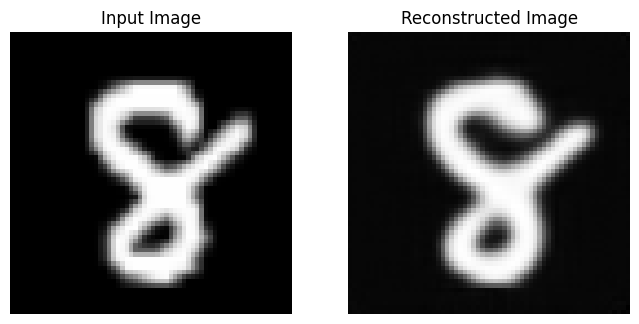

In [ ]:
# Get one sample
data_loader1 = DataLoader(subset_data_set,batch_size=1,shuffle=True)
data_iter = iter(data_loader1)
img, label = next(data_iter)  # img shape: (1,1,64,64)

# Pass through model
model.eval()
with torch.no_grad():
    output, _ = model(img)

# Prepare for plotting
input_img = img.squeeze().cpu().numpy()
output_img = output.squeeze().cpu().numpy()

# De-normalize if needed (from [-1,1] back to [0,1])
input_img = (input_img * 0.5) + 0.5
output_img = (output_img * 0.5) + 0.5

# Plot side by side
plt.figure(figsize=(8,4))

# Input
plt.subplot(1,2,1)
plt.imshow(input_img, cmap='gray')
plt.title("Input Image")
plt.axis('off')

# Output
plt.subplot(1,2,2)
plt.imshow(output_img, cmap='gray')
plt.title("Reconstructed Image")
plt.axis('off')

plt.show()

## (a) (20 points) Plot the t-sne (use inbuilt function) on the embeddings obtained using the respective auto-encoders. Color the clusters using the respective ground-truth class labels.

In [ ]:
model=SparseAutoEncoder(1)
model.load_state_dict(torch.load('Unet_sparse_autoencoder.pkl'))

<All keys matched successfully>

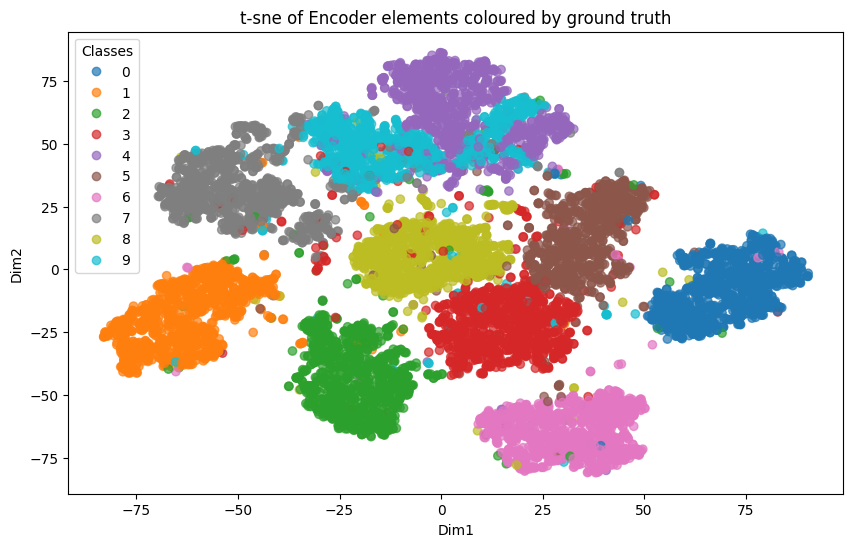

In [ ]:
subset_indices=list(range(10000))
subset_data_set=Subset(train_dataset,subset_indices)
data_loader_eval = DataLoader(subset_data_set,batch_size=100,shuffle=True)
embeddings= []
labels=[]

model.eval()
with torch.no_grad():
    for data,label in data_loader_eval:
        data.to(device)

        # encoder Embeddings
        encoder_embeddings=model.encoder(data)

        #Flatening the sample for t-sne
        encoder_embeddings_flattened=encoder_embeddings.view(encoder_embeddings.size(0),-1)

        embeddings.append(encoder_embeddings_flattened)
        labels.append(label)

#concatinate the embeddings and labels
embeddings=torch.cat(embeddings,dim=0)
labels=torch.cat(labels,dim=0)

#Apply t-sne
tsne= TSNE(n_components=2,random_state=42)
embeddings_in_2d=tsne.fit_transform(embeddings.detach().numpy())

#Plot
plt.figure(figsize=(10,6))
scatter=plt.scatter(embeddings_in_2d[:,0],embeddings_in_2d[:,1],c=labels,cmap='tab10',alpha=0.7)
plt.legend(*scatter.legend_elements(),title='Classes')
plt.title('t-sne of Encoder elements coloured by ground truth')
plt.xlabel('Dim1')
plt.ylabel('Dim2')
plt.show()

![image.png](attachment:image.png)



In [ ]:
subset_indices=list(range(100))
subset_data_set=Subset(train_dataset,subset_indices)
data_loader_q2 = DataLoader(subset_data_set,batch_size=2,shuffle=True)

In [ ]:
def calculate_psnr(img1,img2,max_value=1):
    '''The images are tensors of same dimension with values [0,1]'''
    mse=torch.mean((img1-img2)**2)
    if mse==0:
        return float('inf')
    else:
        psnr_value=20*torch.log10(max_value/mse)
    return psnr_value
def l2norm(img1,img2):
    l2diff=torch.norm(img1-img2,p=2)
    return l2diff


--------------------------------> For the image Pair 1 <--------------------------------



/tmp/ipykernel_192403/394270522.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mse=torch.mean((img1-img2)**2)
/tmp/ipykernel_192403/394270522.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  l2diff=torch.norm(img1-img2,p=2)


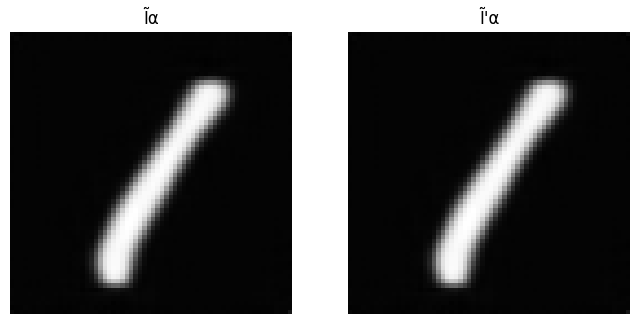

PSNR Value -1.4369747638702393 ----- L2 value 69.51912689208984


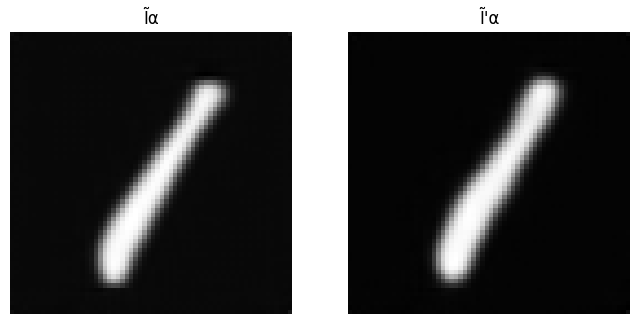

PSNR Value 0.8075327277183533 ----- L2 value 61.09303283691406


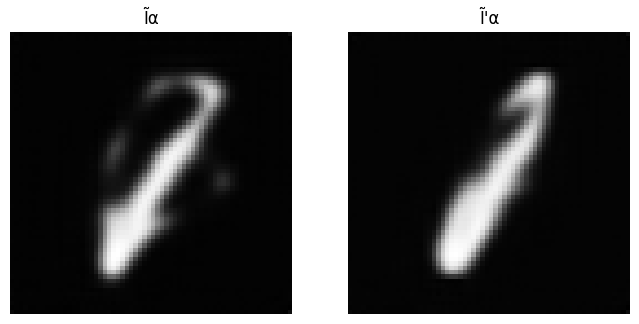

PSNR Value 0.9500029683113098 ----- L2 value 60.59403991699219


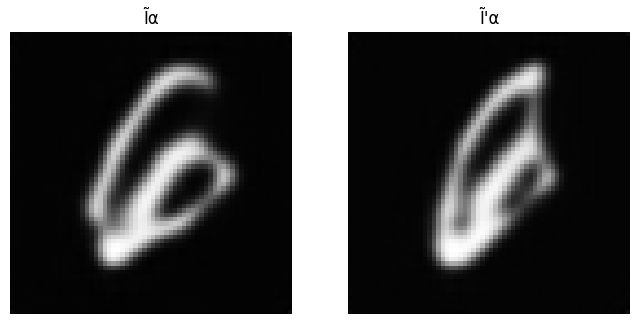

PSNR Value 1.177293300628662 ----- L2 value 59.806396484375


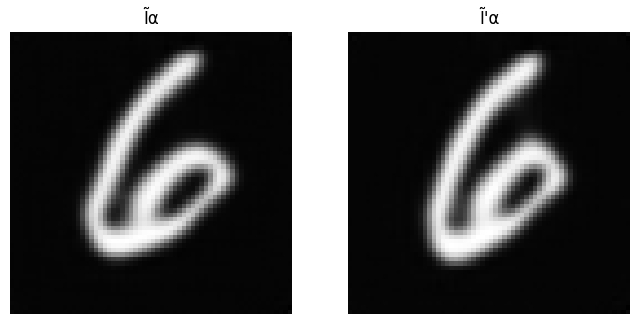

PSNR Value 1.2349776029586792 ----- L2 value 59.60813522338867


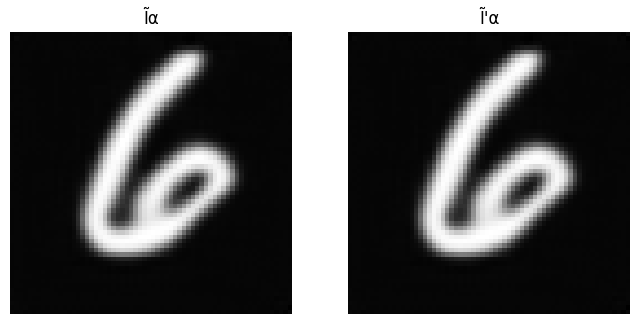

PSNR Value 1.94284188747406 ----- L2 value 57.22804260253906

--------------------------------> For the image Pair 2 <--------------------------------



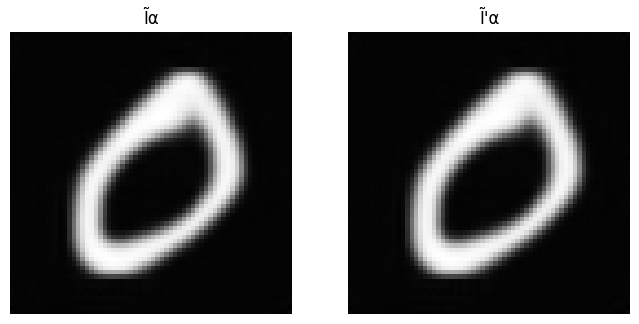

PSNR Value 0.28589165210723877 ----- L2 value 62.955360412597656


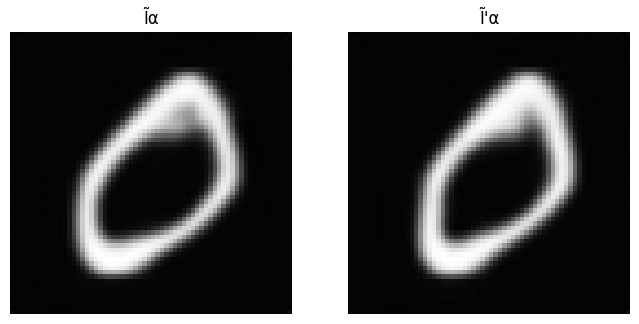

PSNR Value 1.420541763305664 ----- L2 value 58.97480010986328


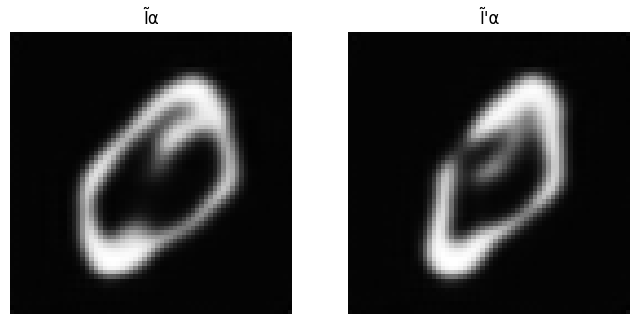

PSNR Value 1.1990307569503784 ----- L2 value 59.73160934448242


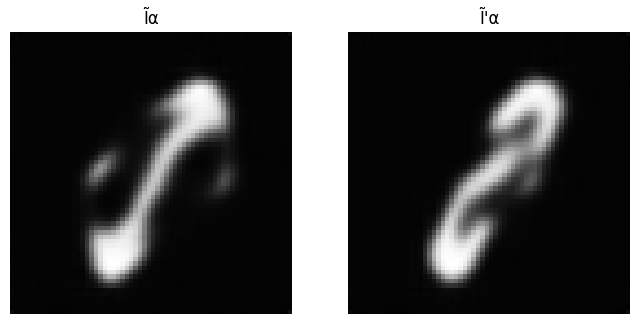

PSNR Value 0.2937560975551605 ----- L2 value 62.92686462402344


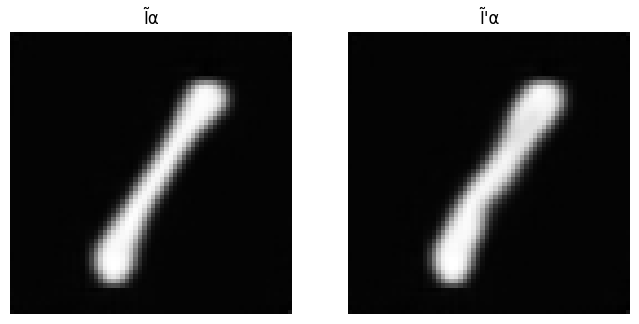

PSNR Value 0.4077797532081604 ----- L2 value 62.515174865722656


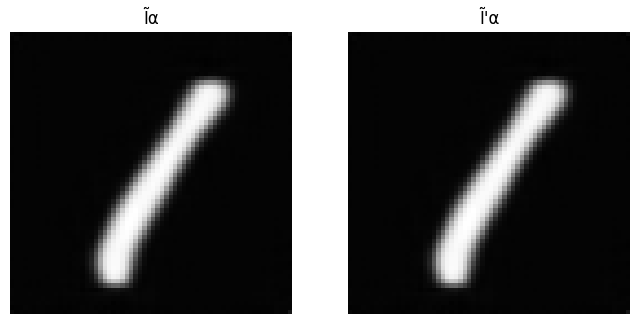

PSNR Value 1.0361377000808716 ----- L2 value 60.29434585571289

--------------------------------> For the image Pair 3 <--------------------------------



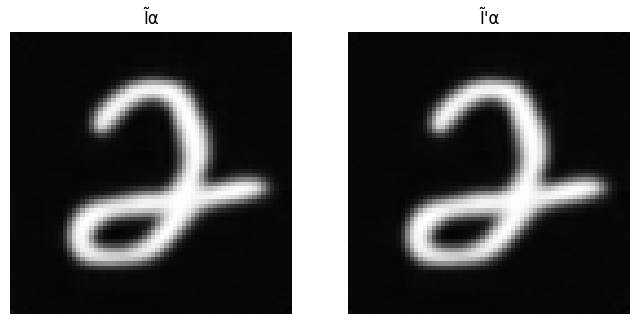

PSNR Value 0.3460172414779663 ----- L2 value 62.73784255981445


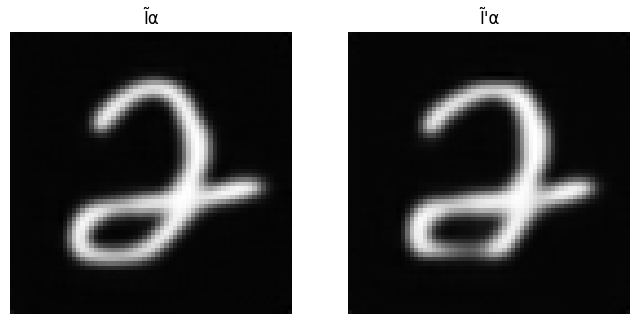

PSNR Value 1.218047857284546 ----- L2 value 59.6662483215332


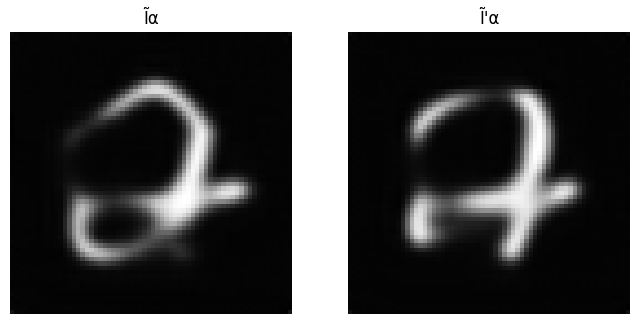

PSNR Value 0.6933841705322266 ----- L2 value 61.49578094482422


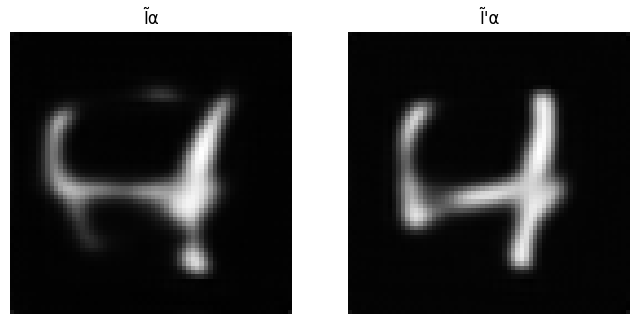

PSNR Value 0.3689257502555847 ----- L2 value 62.65515899658203


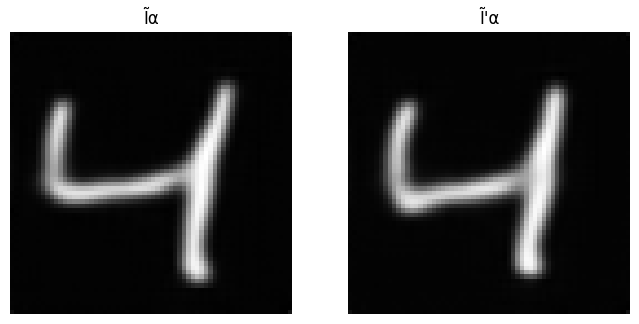

PSNR Value 0.6292503476142883 ----- L2 value 61.72323226928711


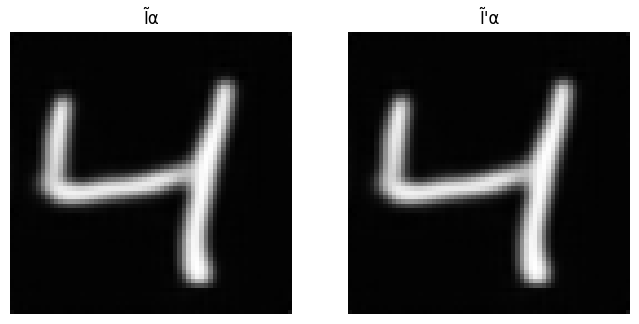

PSNR Value 1.3106156587600708 ----- L2 value 59.34916305541992

--------------------------------> For the image Pair 4 <--------------------------------



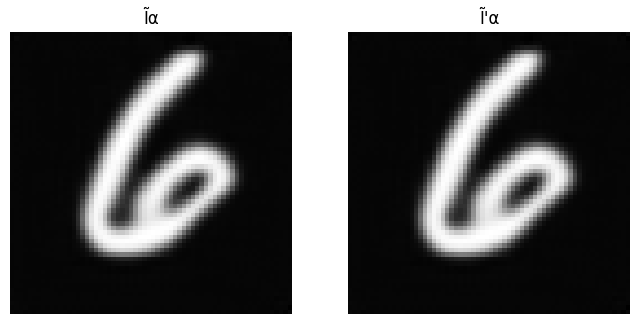

PSNR Value 0.04045652225613594 ----- L2 value 63.85111999511719


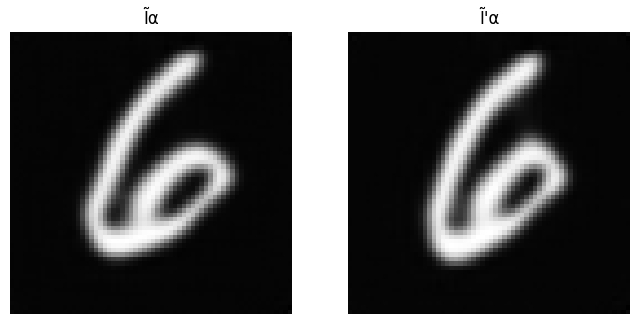

PSNR Value 1.2955635786056519 ----- L2 value 59.40060806274414


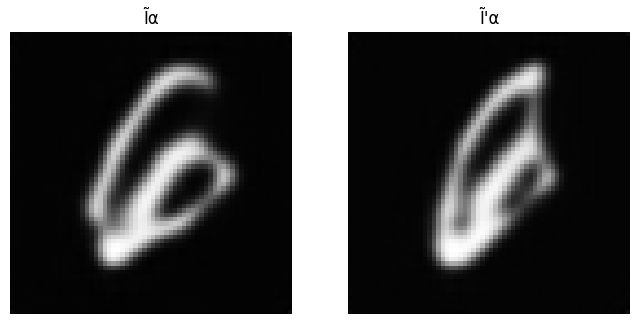

PSNR Value 1.0464190244674683 ----- L2 value 60.2586555480957


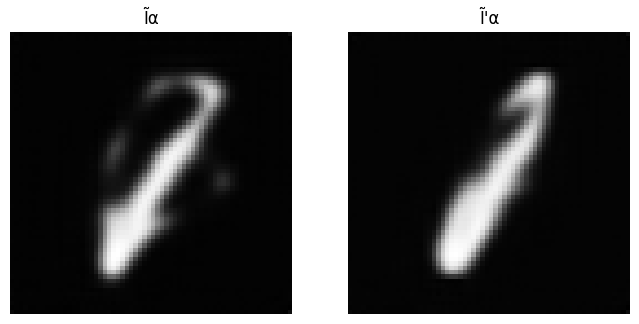

PSNR Value 0.3970874845981598 ----- L2 value 62.55366516113281


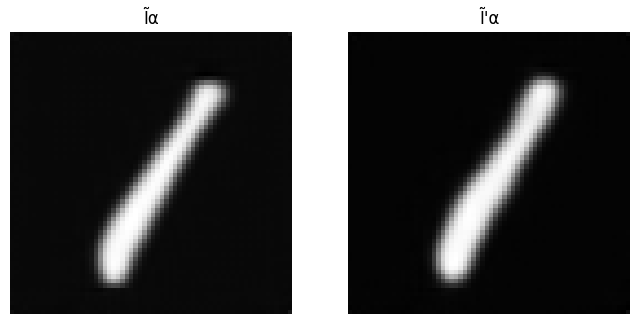

PSNR Value 0.6700562834739685 ----- L2 value 61.57843017578125


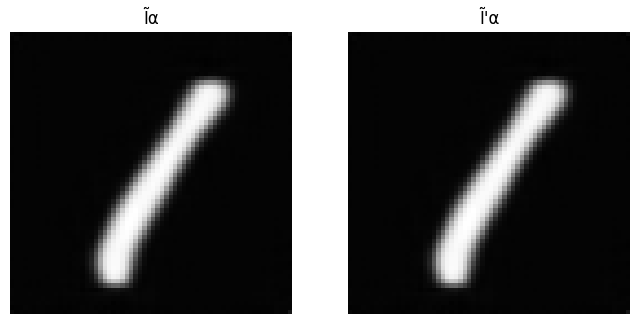

PSNR Value 1.0977191925048828 ----- L2 value 60.08097457885742

--------------------------------> For the image Pair 5 <--------------------------------



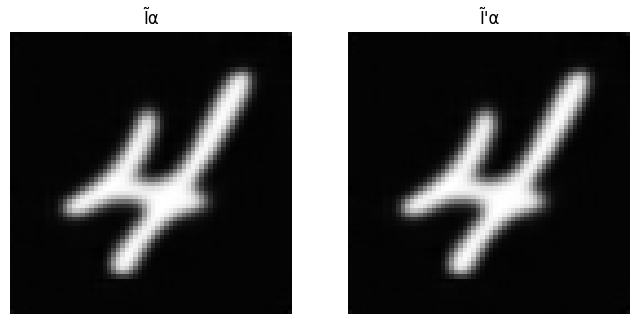

PSNR Value 0.09534604102373123 ----- L2 value 63.649696350097656


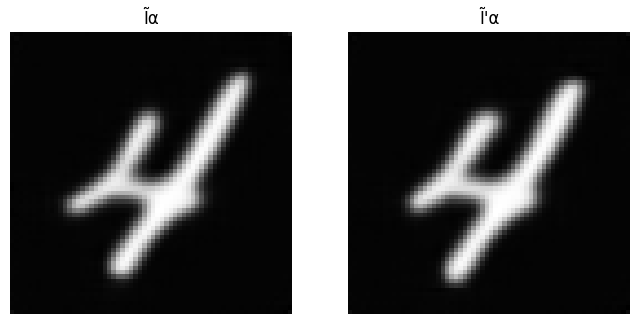

PSNR Value 1.266303300857544 ----- L2 value 59.50074768066406


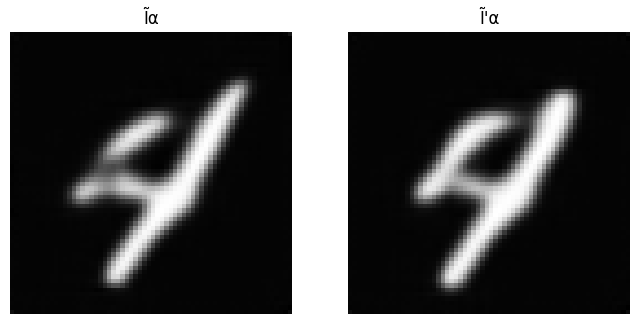

PSNR Value 1.250731348991394 ----- L2 value 59.554100036621094


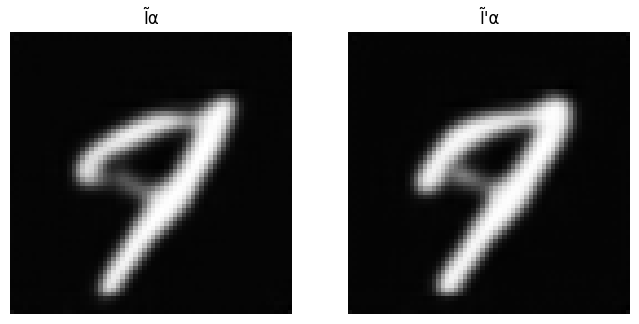

PSNR Value 1.1691137552261353 ----- L2 value 59.83456039428711


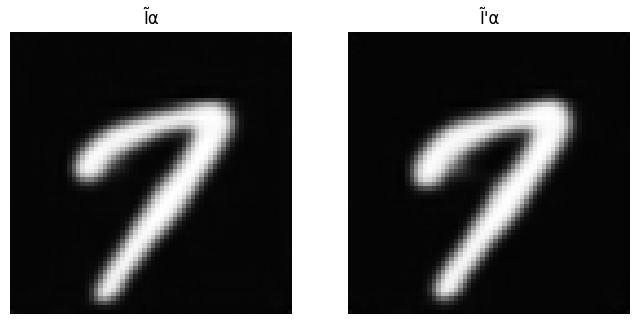

PSNR Value 1.3528167009353638 ----- L2 value 59.20516586303711


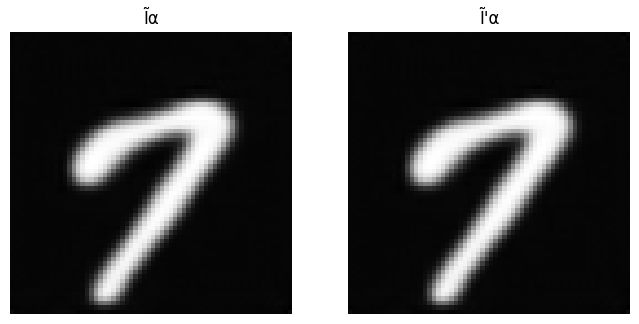

PSNR Value 1.7198166847229004 ----- L2 value 57.96750259399414

--------------------------------> For the image Pair 6 <--------------------------------



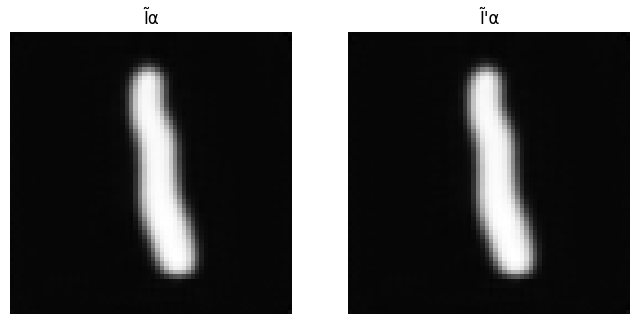

PSNR Value -1.3697717189788818 ----- L2 value 69.25072479248047


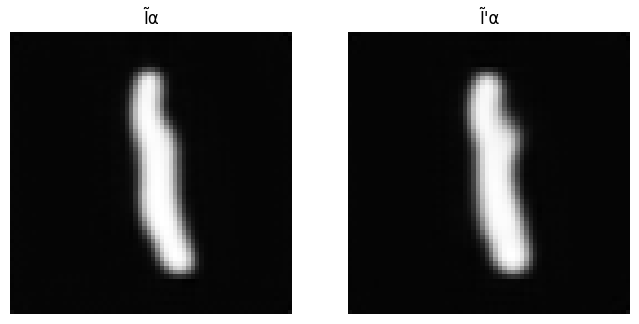

PSNR Value 0.8926904797554016 ----- L2 value 60.794281005859375


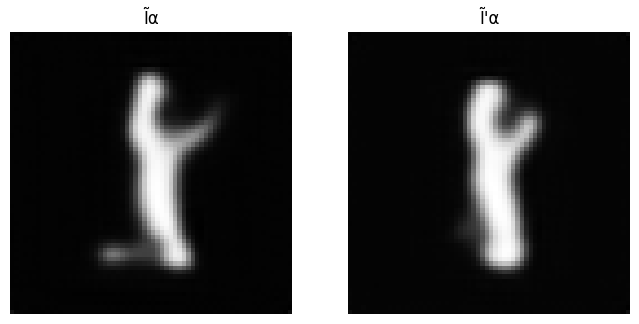

PSNR Value 1.0320149660110474 ----- L2 value 60.30865478515625


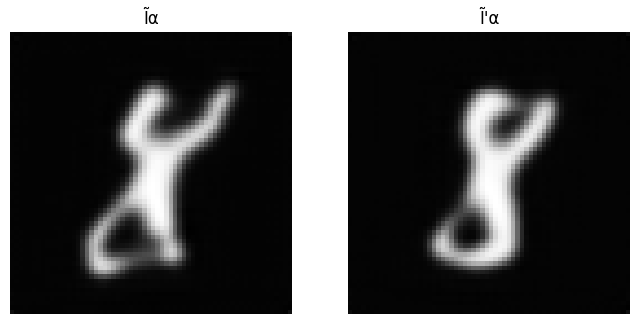

PSNR Value 1.2705230712890625 ----- L2 value 59.486289978027344


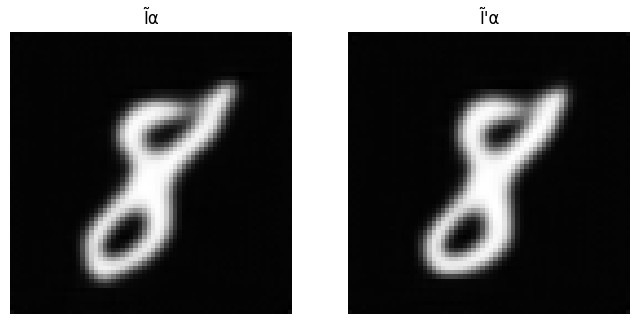

PSNR Value 1.2909214496612549 ----- L2 value 59.41648483276367


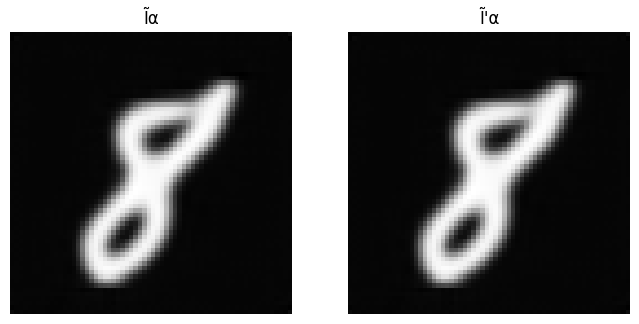

PSNR Value 1.794783353805542 ----- L2 value 57.7178840637207

--------------------------------> For the image Pair 7 <--------------------------------



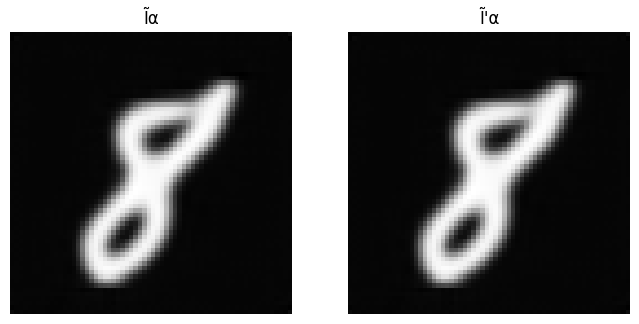

PSNR Value 1.7711281776428223 ----- L2 value 57.79652786254883


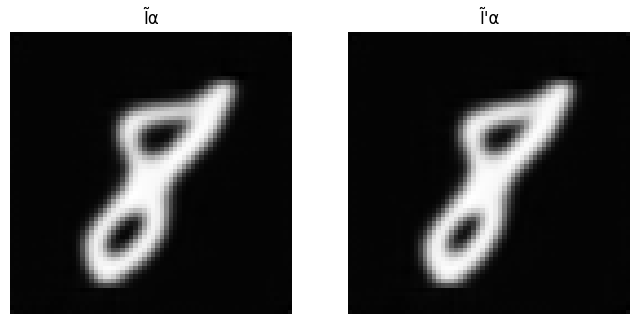

PSNR Value 1.4079843759536743 ----- L2 value 59.0174446105957


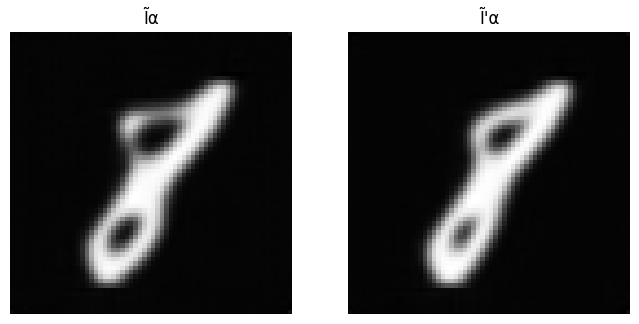

PSNR Value 1.1742284297943115 ----- L2 value 59.81694793701172


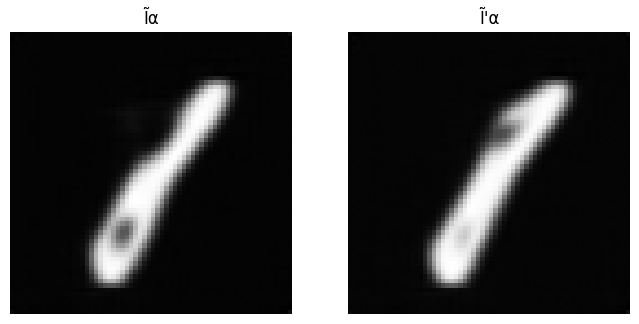

PSNR Value 0.7765889167785645 ----- L2 value 61.20195007324219


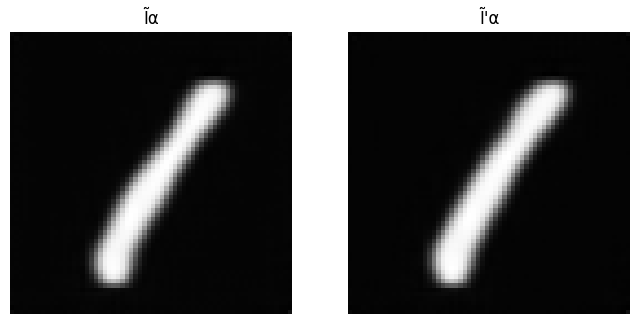

PSNR Value 0.8980041742324829 ----- L2 value 60.77568817138672


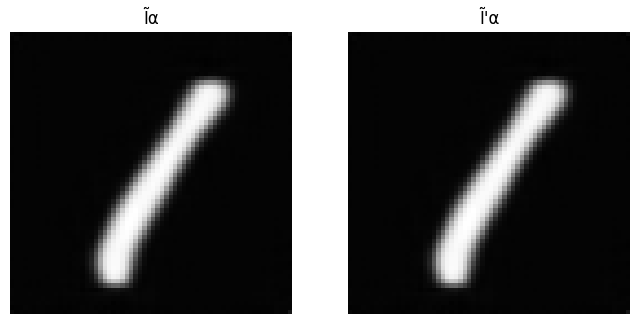

PSNR Value 1.0379709005355835 ----- L2 value 60.28797149658203

--------------------------------> For the image Pair 8 <--------------------------------



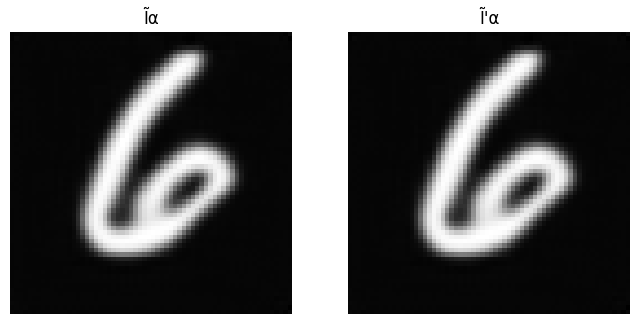

PSNR Value 0.3319355249404907 ----- L2 value 62.78871536254883


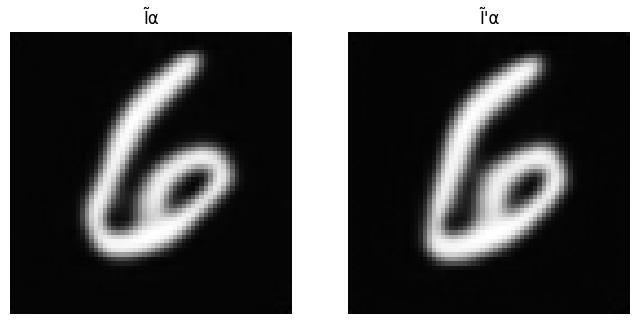

PSNR Value 1.537642478942871 ----- L2 value 58.578590393066406


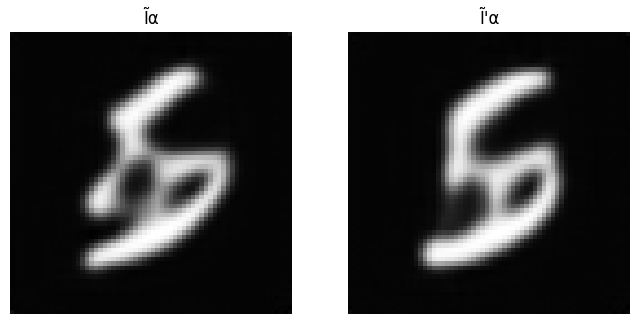

PSNR Value 1.3054782152175903 ----- L2 value 59.36672592163086


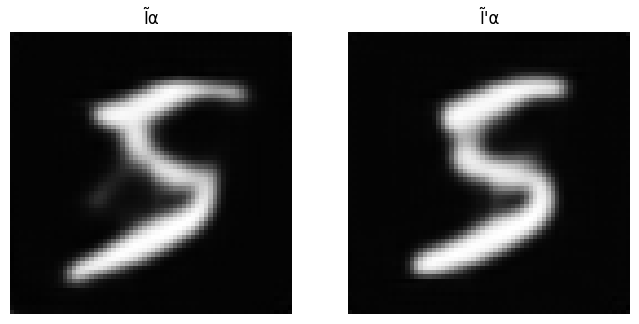

PSNR Value 0.9889882206916809 ----- L2 value 60.45819854736328


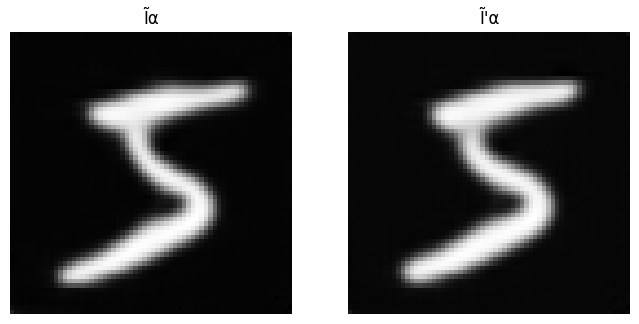

PSNR Value 1.2983789443969727 ----- L2 value 59.3909797668457


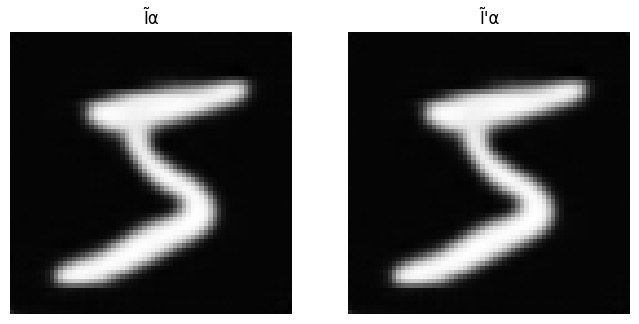

PSNR Value 1.8671553134918213 ----- L2 value 57.477928161621094

--------------------------------> For the image Pair 9 <--------------------------------



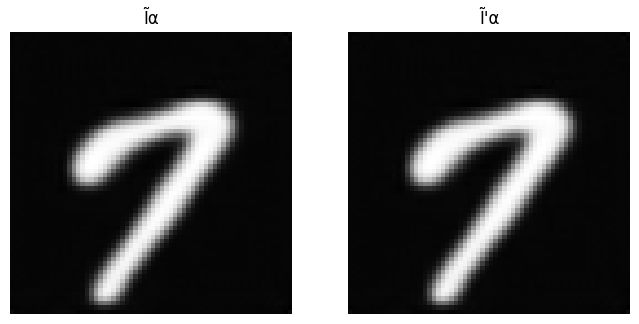

PSNR Value -0.6222977638244629 ----- L2 value 66.33418273925781


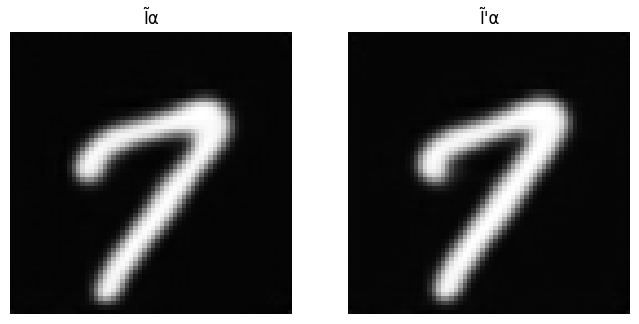

PSNR Value 1.1742700338363647 ----- L2 value 59.81680679321289


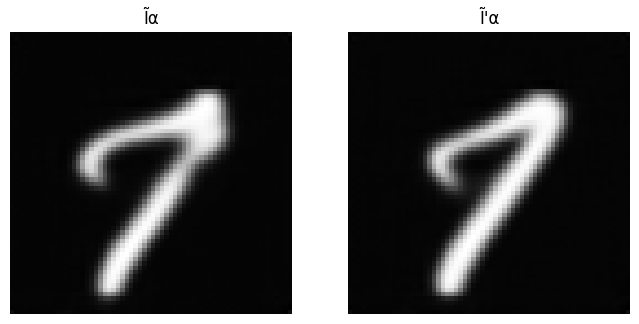

PSNR Value 1.0360227823257446 ----- L2 value 60.294734954833984


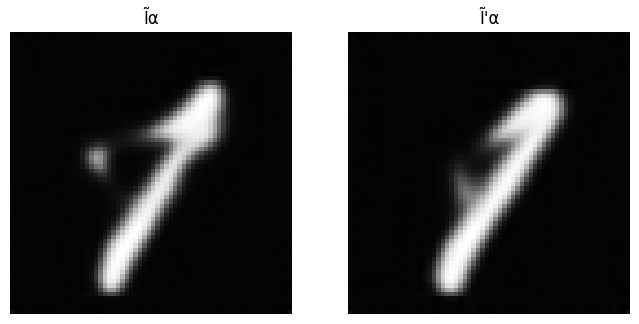

PSNR Value 0.5918390154838562 ----- L2 value 61.85630798339844


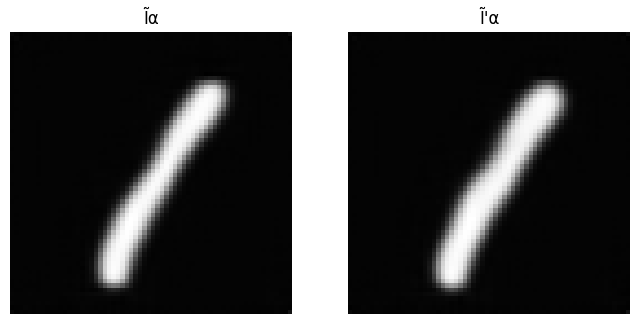

PSNR Value 0.659153401851654 ----- L2 value 61.61708068847656


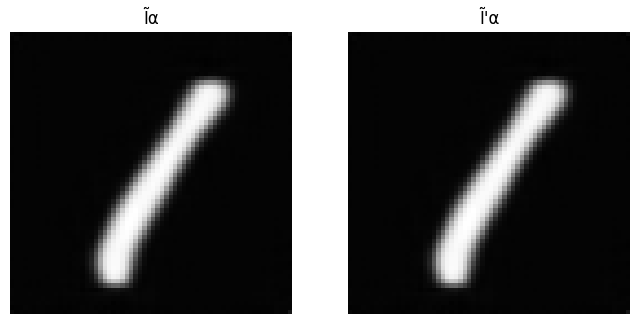

PSNR Value 1.045625925064087 ----- L2 value 60.261417388916016

--------------------------------> For the image Pair 10 <--------------------------------



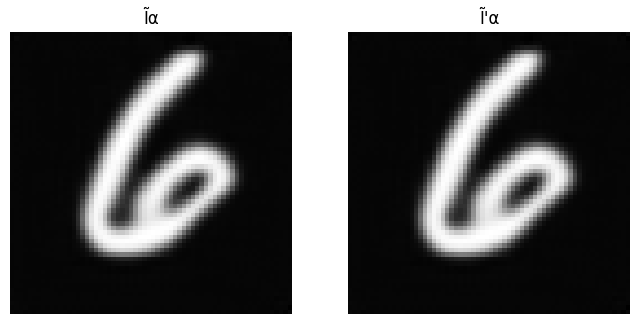

PSNR Value 0.3319355249404907 ----- L2 value 62.78871536254883


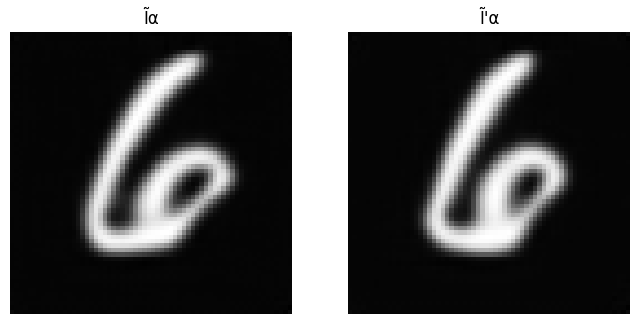

PSNR Value 1.4313466548919678 ----- L2 value 58.93811798095703


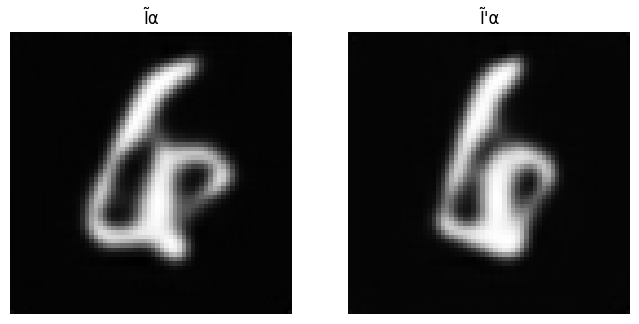

PSNR Value 1.2030948400497437 ----- L2 value 59.71763610839844


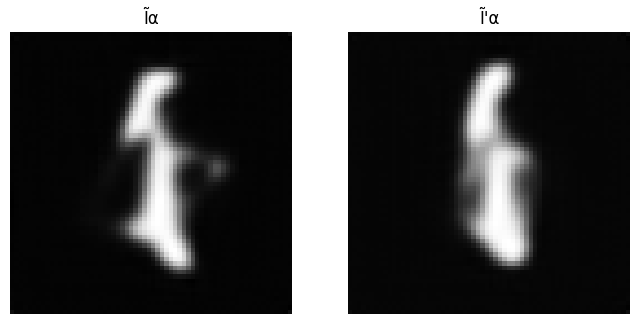

PSNR Value 0.4642292261123657 ----- L2 value 62.3123664855957


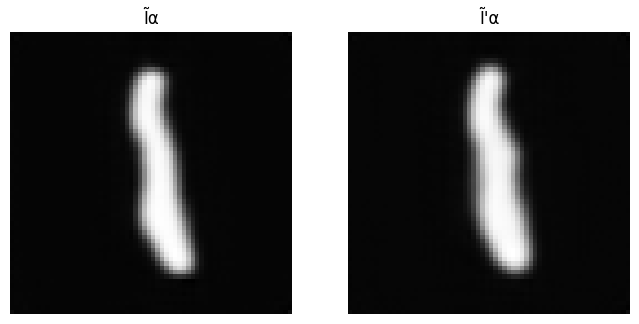

PSNR Value 0.7160184383392334 ----- L2 value 61.41571807861328


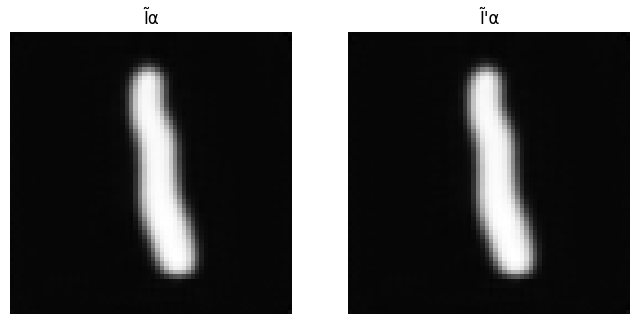

PSNR Value 1.0666391849517822 ----- L2 value 60.18856430053711

--------------------------------> For the image Pair 11 <--------------------------------



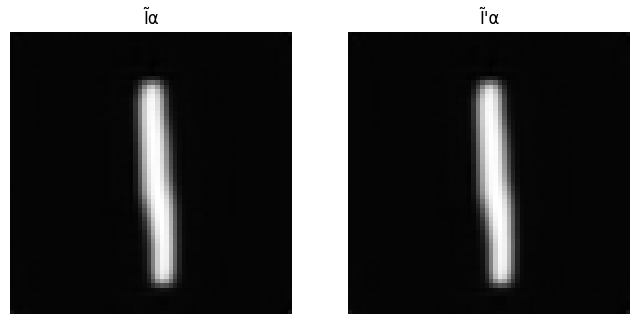

PSNR Value 0.07060769200325012 ----- L2 value 63.74040222167969


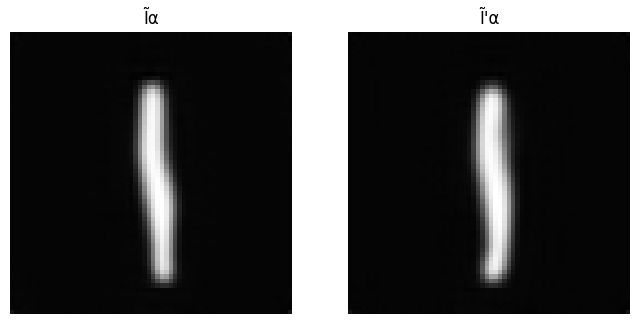

PSNR Value 0.6541064381599426 ----- L2 value 61.63499450683594


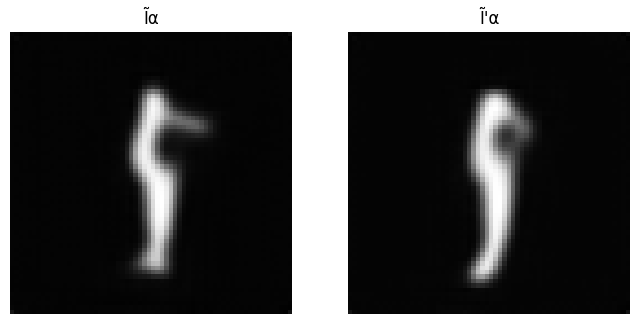

PSNR Value 0.7052275538444519 ----- L2 value 61.45387268066406


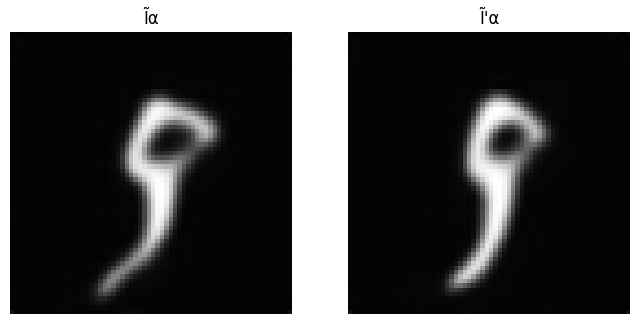

PSNR Value 0.8379172682762146 ----- L2 value 60.986263275146484


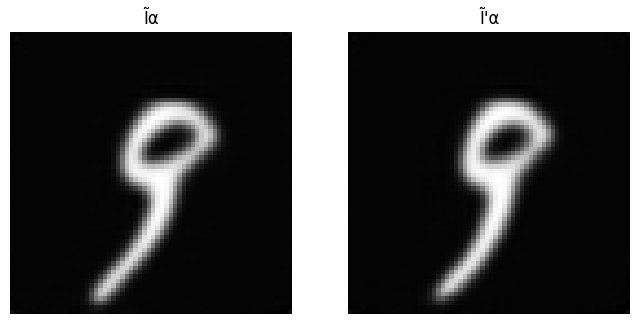

PSNR Value 0.989879846572876 ----- L2 value 60.45510482788086


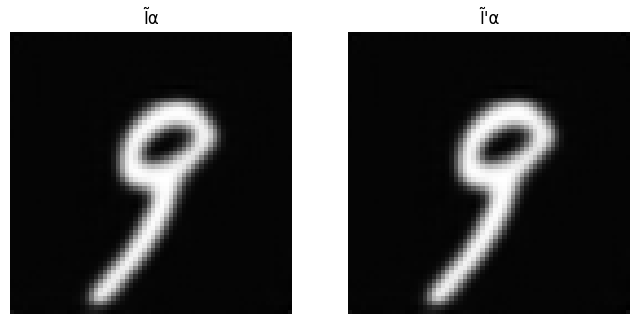

PSNR Value 1.2503430843353271 ----- L2 value 59.5554313659668

--------------------------------> For the image Pair 12 <--------------------------------



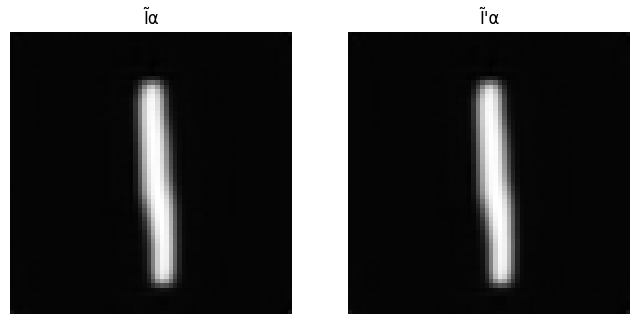

PSNR Value -0.606042742729187 ----- L2 value 66.27214813232422


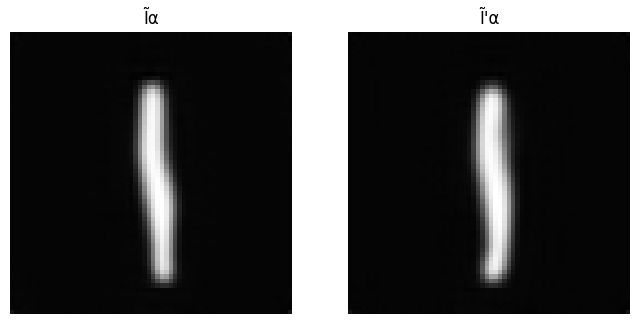

PSNR Value 0.6541064381599426 ----- L2 value 61.63499450683594


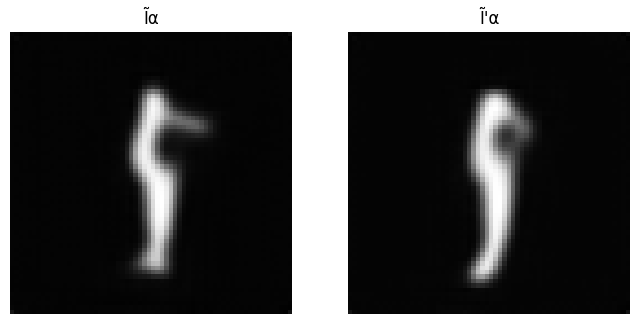

PSNR Value 0.7052275538444519 ----- L2 value 61.45387268066406


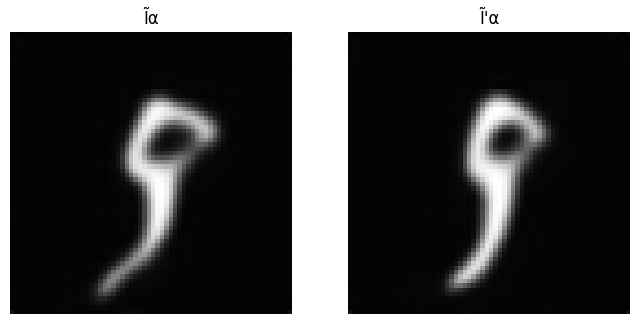

PSNR Value 0.8379172682762146 ----- L2 value 60.986263275146484


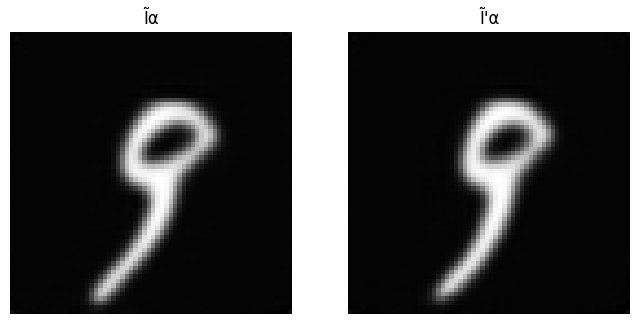

PSNR Value 0.989879846572876 ----- L2 value 60.45510482788086


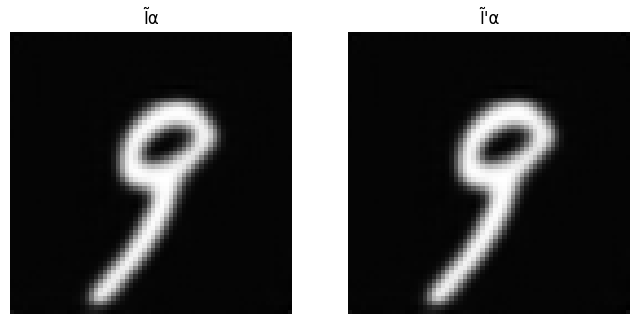

PSNR Value 1.2503430843353271 ----- L2 value 59.5554313659668

--------------------------------> For the image Pair 13 <--------------------------------



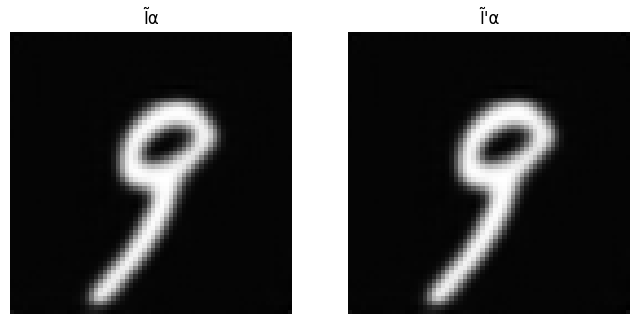

PSNR Value 1.198991060256958 ----- L2 value 59.73174285888672


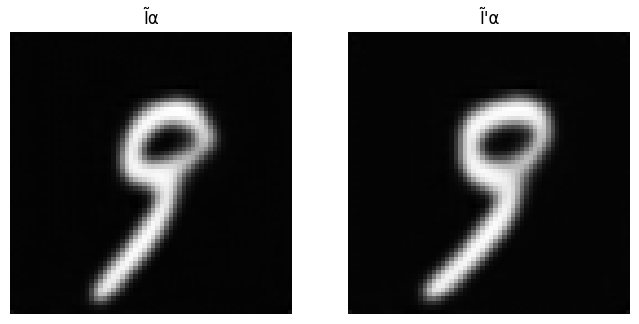

PSNR Value 1.0302724838256836 ----- L2 value 60.314701080322266


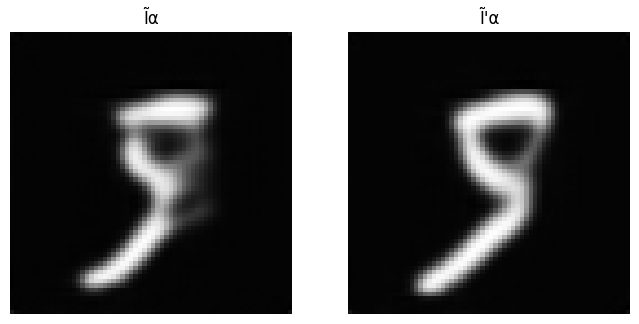

PSNR Value 1.0641487836837769 ----- L2 value 60.19719314575195


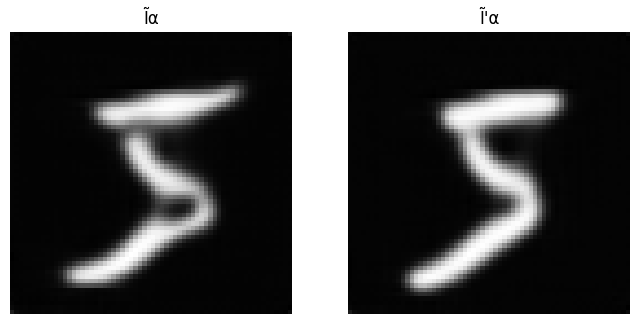

PSNR Value 1.2412663698196411 ----- L2 value 59.5865592956543


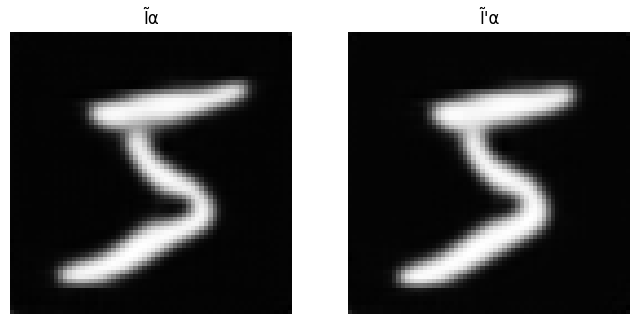

PSNR Value 1.5641199350357056 ----- L2 value 58.48937225341797


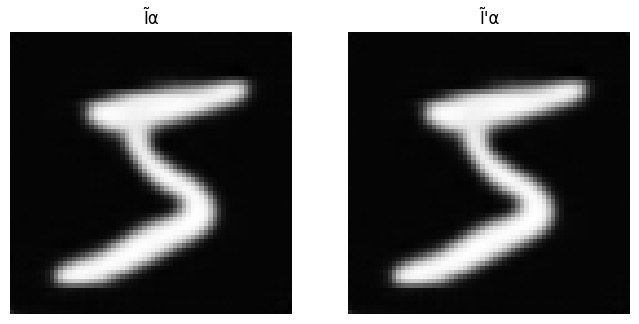

PSNR Value 1.9698708057403564 ----- L2 value 57.13907241821289

--------------------------------> For the image Pair 14 <--------------------------------



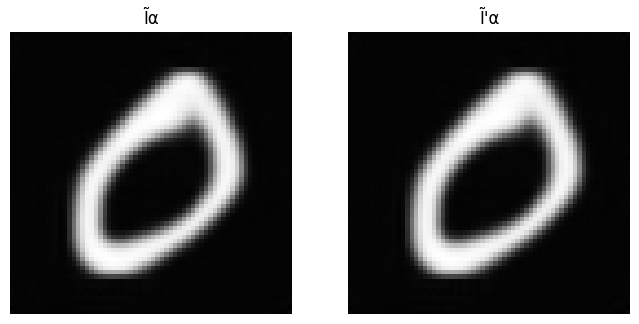

PSNR Value 0.4117128551006317 ----- L2 value 62.50102615356445


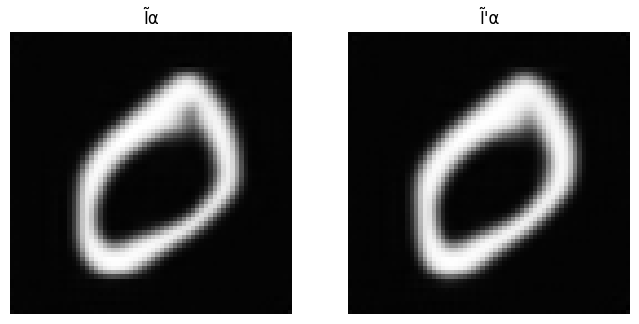

PSNR Value 1.6174088716506958 ----- L2 value 58.31023025512695


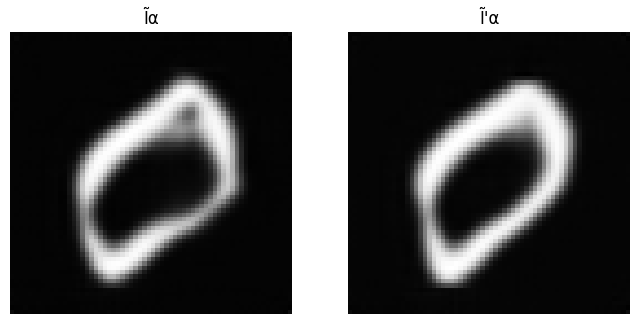

PSNR Value 1.471989631652832 ----- L2 value 58.80039596557617


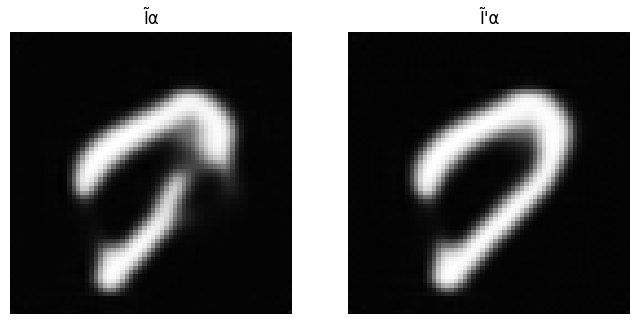

PSNR Value 0.9396961331367493 ----- L2 value 60.62998962402344


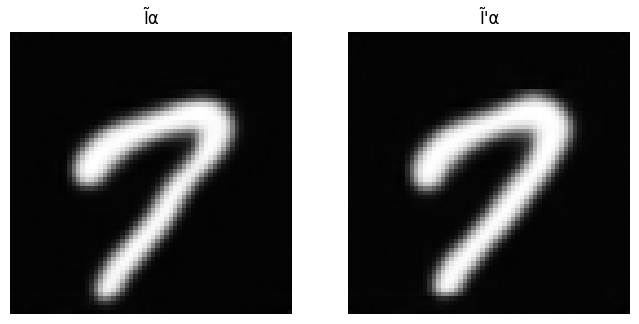

PSNR Value 1.0899237394332886 ----- L2 value 60.10794448852539


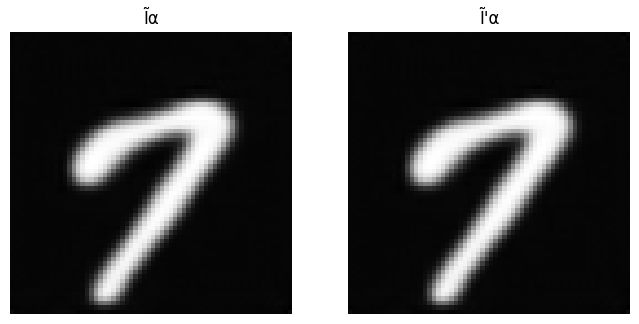

PSNR Value 1.565966010093689 ----- L2 value 58.483154296875

--------------------------------> For the image Pair 15 <--------------------------------



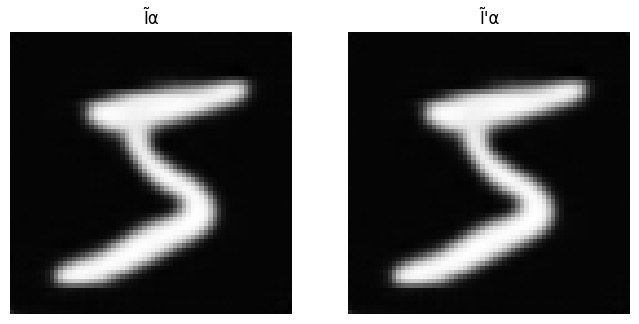

PSNR Value -0.18705600500106812 ----- L2 value 64.69285583496094


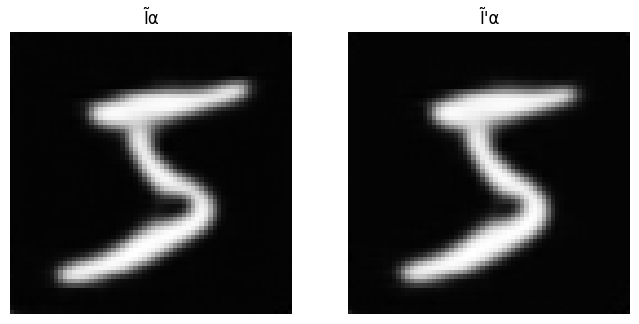

PSNR Value 1.2477720975875854 ----- L2 value 59.56425094604492


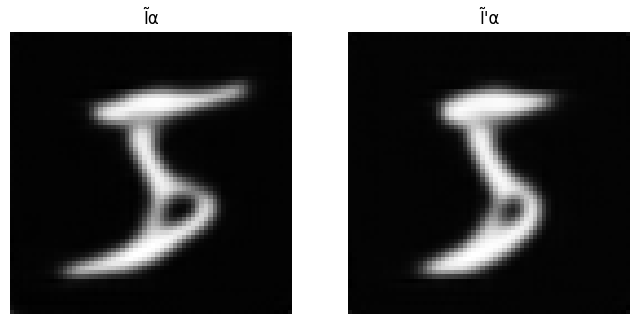

PSNR Value 0.9840553998947144 ----- L2 value 60.475379943847656


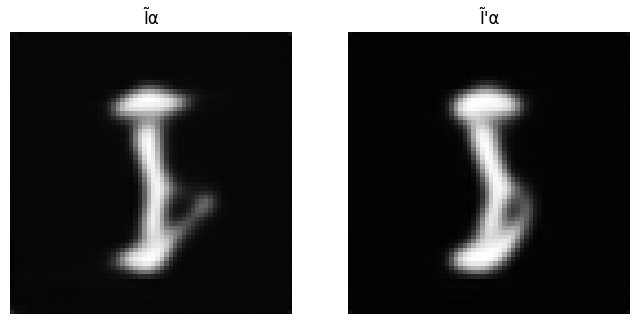

PSNR Value 0.2843555808067322 ----- L2 value 62.9609260559082


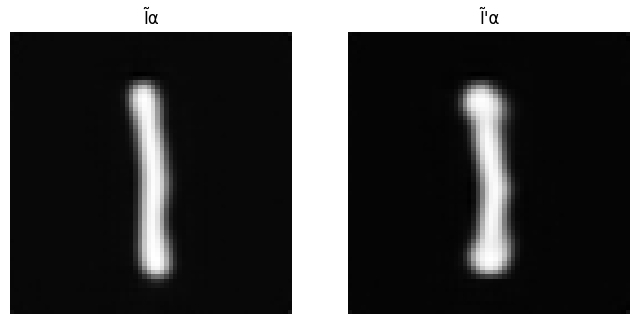

PSNR Value 0.22636891901493073 ----- L2 value 63.17144012451172


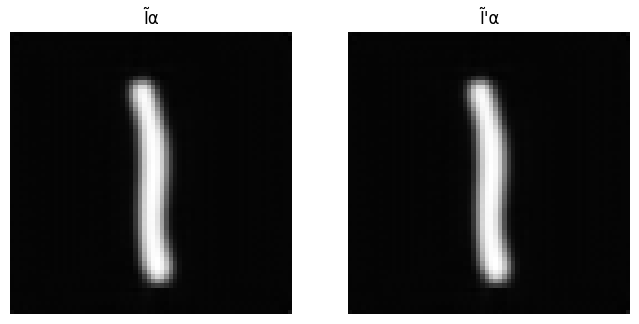

PSNR Value 0.662075400352478 ----- L2 value 61.60672378540039

--------------------------------> For the image Pair 16 <--------------------------------



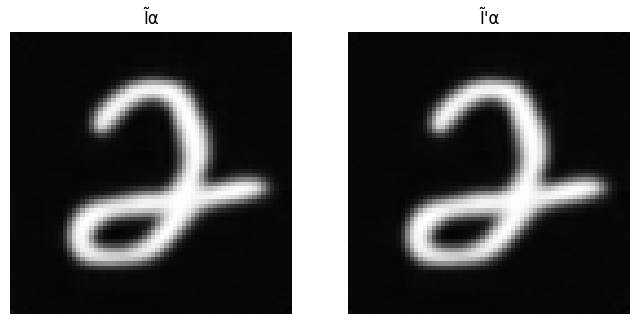

PSNR Value 0.7127357721328735 ----- L2 value 61.42731857299805


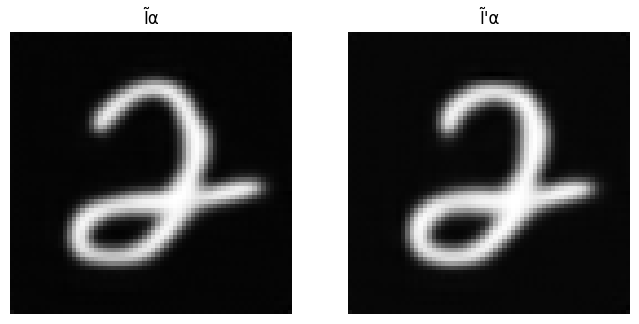

PSNR Value 1.3550653457641602 ----- L2 value 59.1974983215332


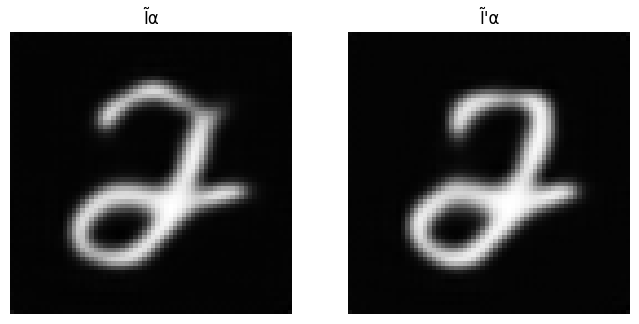

PSNR Value 1.1186470985412598 ----- L2 value 60.00864028930664


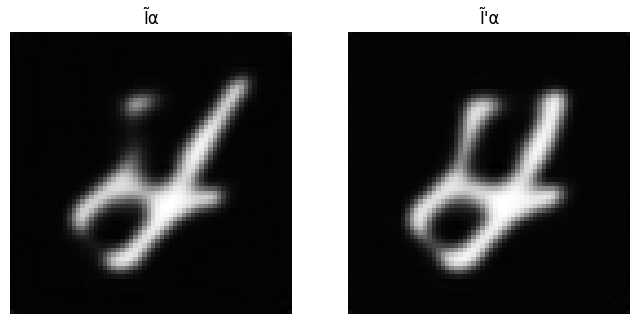

PSNR Value 0.608366847038269 ----- L2 value 61.7974853515625


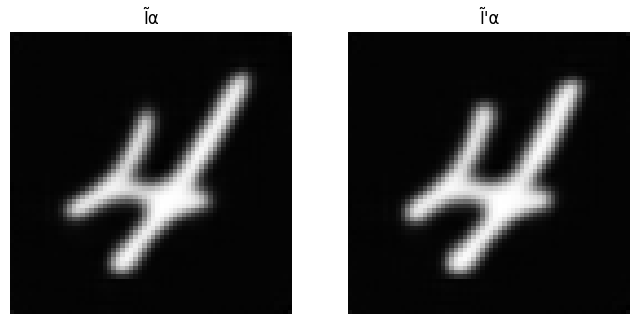

PSNR Value 0.9160047173500061 ----- L2 value 60.71273422241211


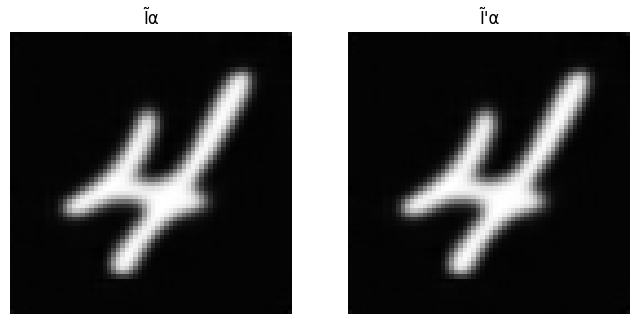

PSNR Value 1.4555169343948364 ----- L2 value 58.856178283691406

--------------------------------> For the image Pair 17 <--------------------------------



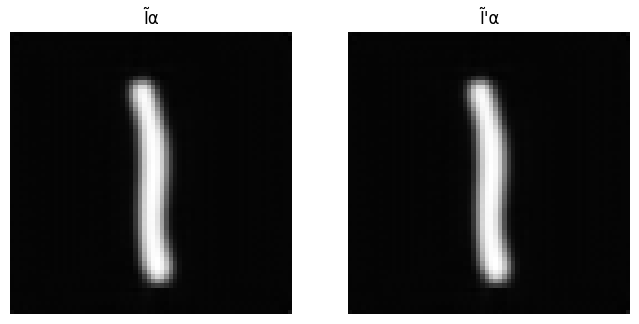

PSNR Value -1.2022266387939453 ----- L2 value 68.58602905273438


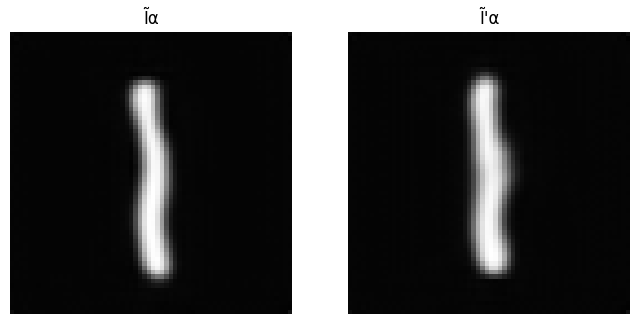

PSNR Value 0.6705182790756226 ----- L2 value 61.5767822265625


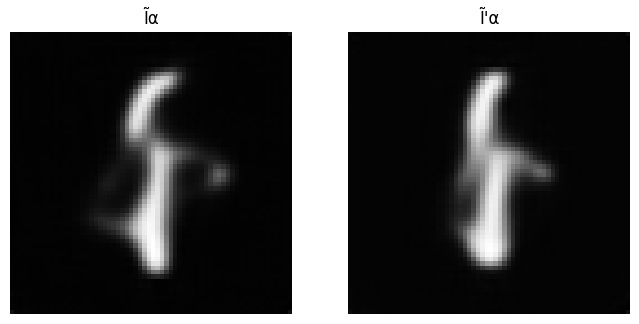

PSNR Value 0.9482569098472595 ----- L2 value 60.60013198852539


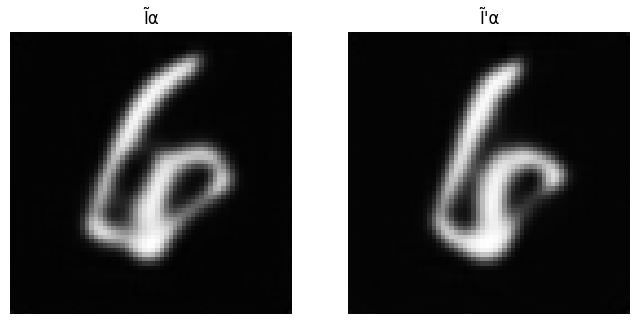

PSNR Value 1.3665714263916016 ----- L2 value 59.15830993652344


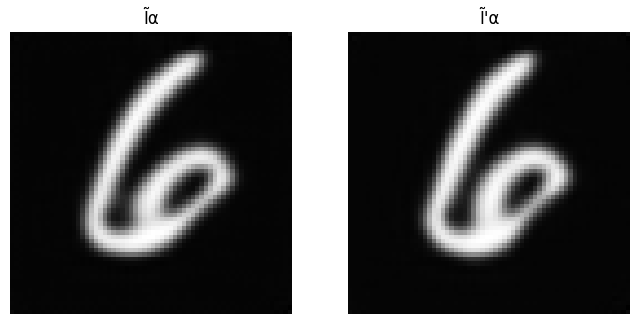

PSNR Value 1.5595568418502808 ----- L2 value 58.50474548339844


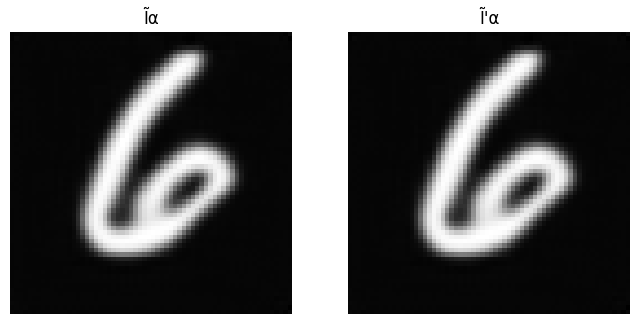

PSNR Value 2.056455373764038 ----- L2 value 56.85498809814453

--------------------------------> For the image Pair 18 <--------------------------------



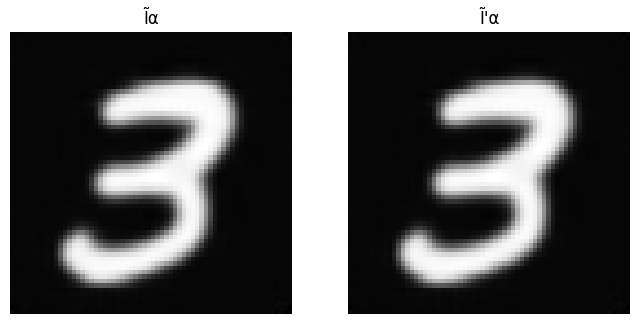

PSNR Value 0.10564067959785461 ----- L2 value 63.61198425292969


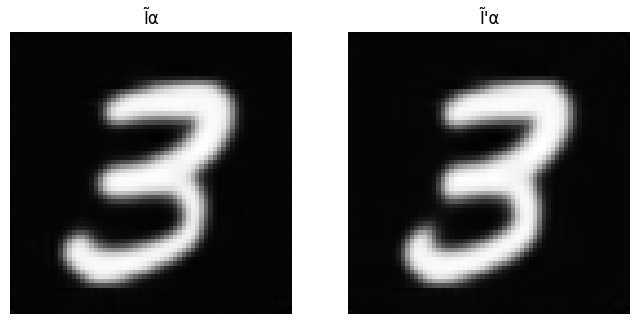

PSNR Value 1.8733073472976685 ----- L2 value 57.45757293701172


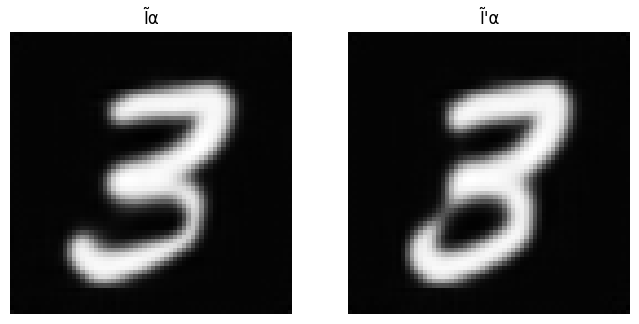

PSNR Value 1.5976855754852295 ----- L2 value 58.376468658447266


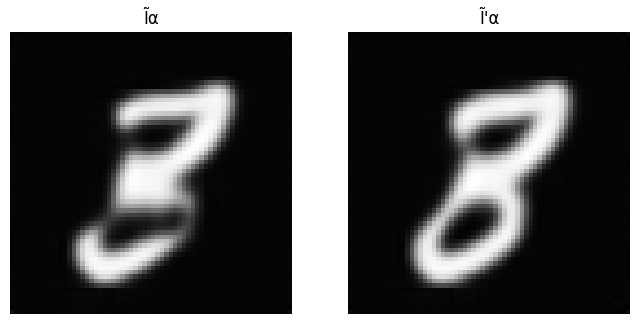

PSNR Value 1.3217637538909912 ----- L2 value 59.31108474731445


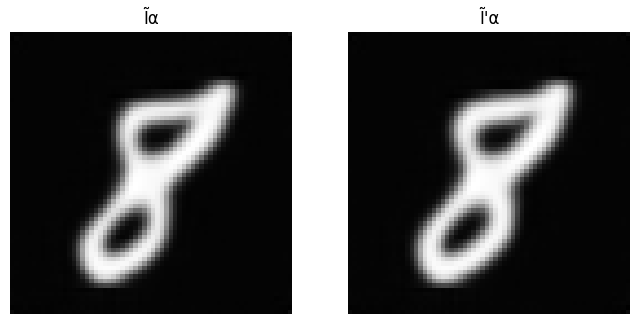

PSNR Value 1.1898181438446045 ----- L2 value 59.7632942199707


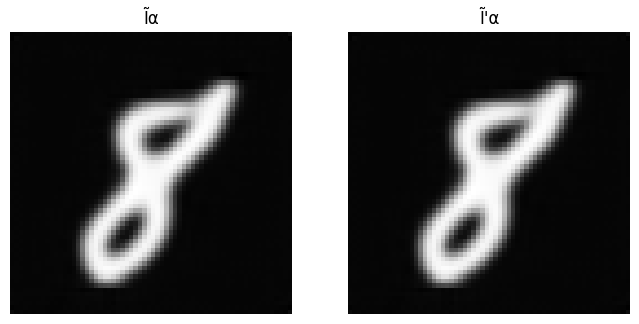

PSNR Value 1.5558968782424927 ----- L2 value 58.51707077026367

--------------------------------> For the image Pair 19 <--------------------------------



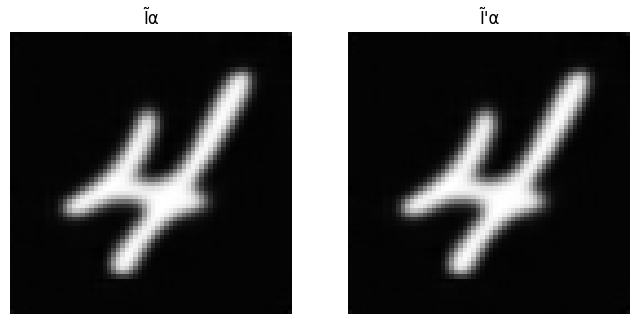

PSNR Value -0.1381250023841858 ----- L2 value 64.51090240478516


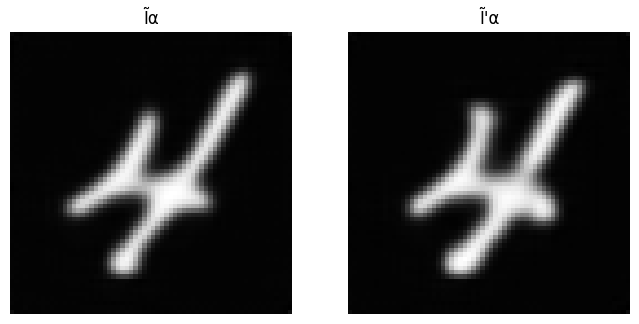

PSNR Value 1.0978752374649048 ----- L2 value 60.080448150634766


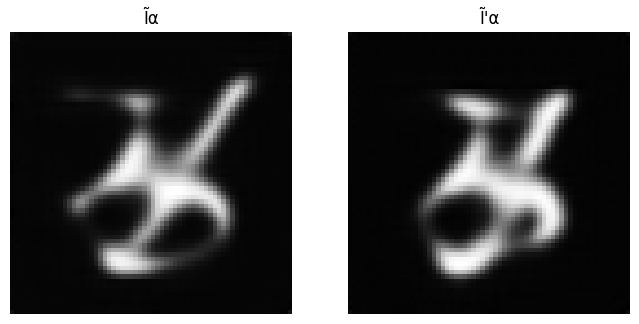

PSNR Value 1.2252041101455688 ----- L2 value 59.64167404174805


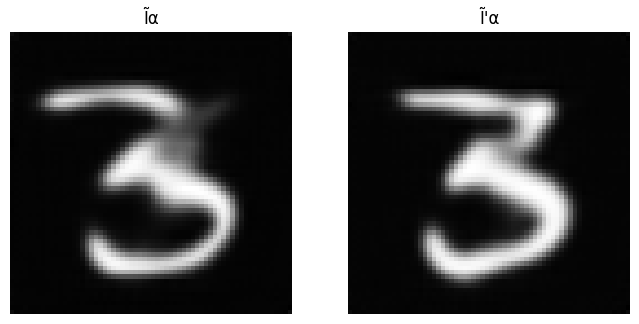

PSNR Value 1.040127158164978 ----- L2 value 60.280494689941406


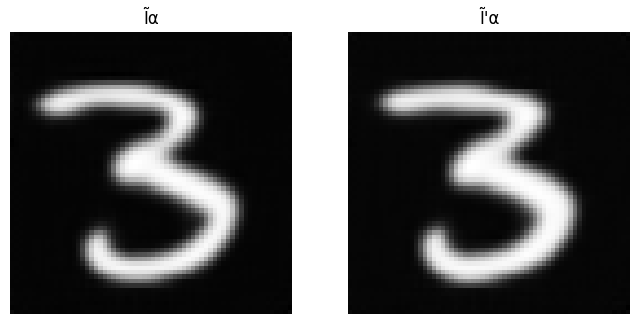

PSNR Value 1.6453968286514282 ----- L2 value 58.21636199951172


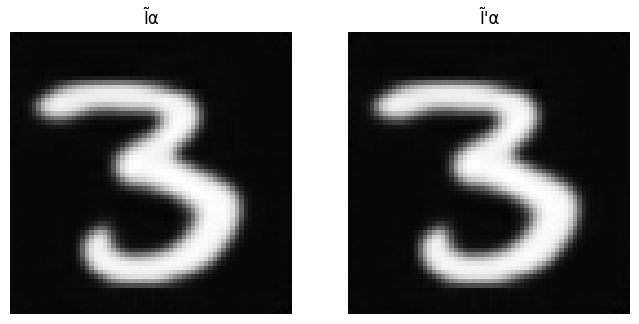

PSNR Value 2.515470027923584 ----- L2 value 55.37238311767578

--------------------------------> For the image Pair 20 <--------------------------------



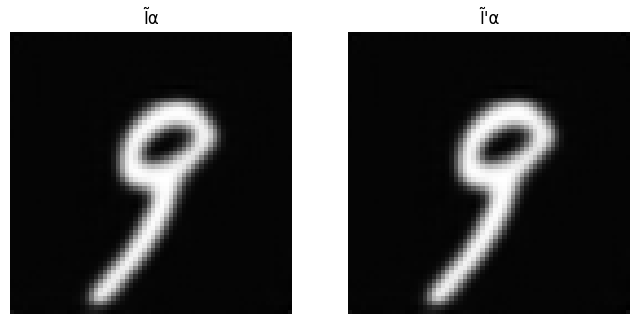

PSNR Value -1.8551390171051025 ----- L2 value 71.21286010742188


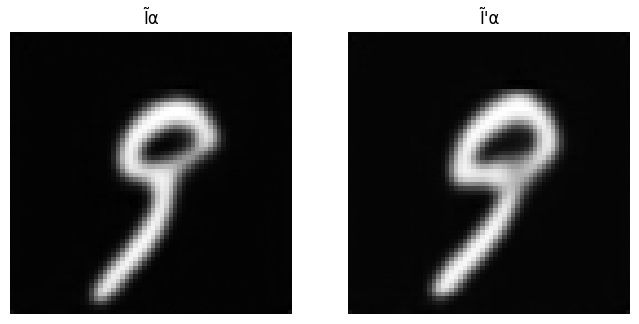

PSNR Value 0.9881066679954529 ----- L2 value 60.46127700805664


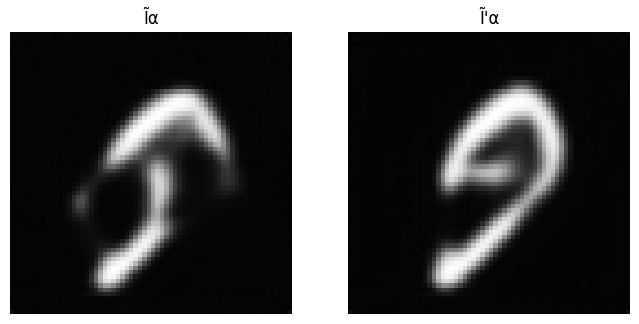

PSNR Value 0.9300096035003662 ----- L2 value 60.66381072998047


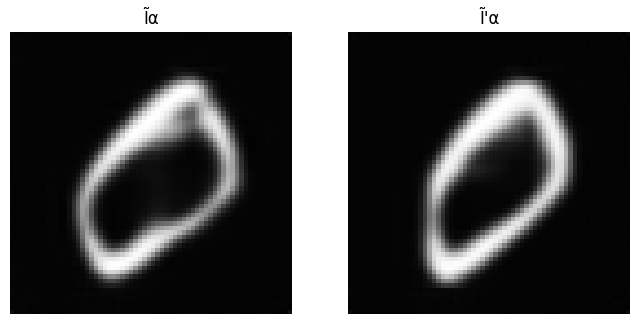

PSNR Value 1.070582628250122 ----- L2 value 60.17490768432617


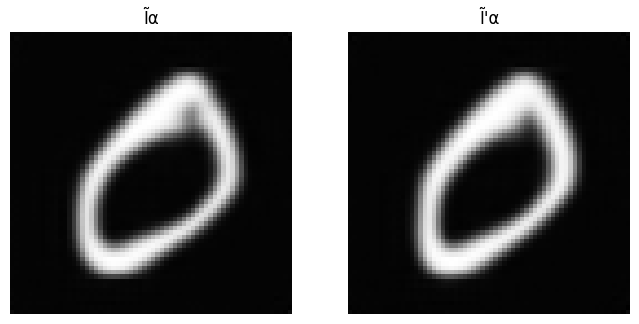

PSNR Value 1.5882163047790527 ----- L2 value 58.408294677734375


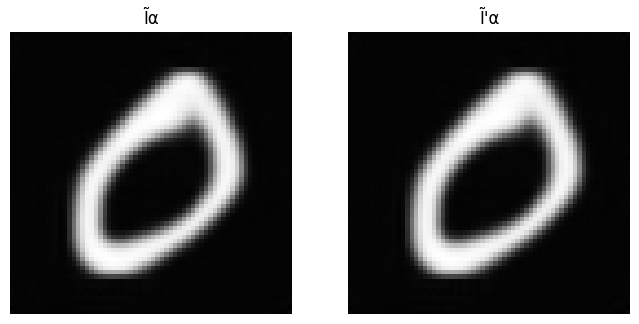

PSNR Value 2.2509334087371826 ----- L2 value 56.222042083740234


In [ ]:
alphas=[0, 0.2, 0.4, 0.6, 0.8, 1.]
for i in range(1,21):
    for featues, labels in data_loader_q2:
        if labels[0]!=labels[1]:
            break
        else:
            pass
    print(f'\n--------------------------------> For the image Pair {i} <--------------------------------\n')
    for alpha in alphas:
        I1=featues[0]
        I2=featues[1]

        I_alpha=alpha*I1+(1-alpha)*I2

        model.eval()
        with torch.no_grad():
            # encoder Embeddings
            h_alpha=model.encoder(I_alpha)
            h1=model.encoder(I1)
            h2=model.encoder(I2)
            
            h_dash_alpha=alpha*h1+(1-alpha)*h2

            h_alpha_bottle_neck=model.bottleneck(h_alpha)
            h_dash_alpha_bottle_neck=model.bottleneck(h_dash_alpha)

            i_alpha_hat=model.decoder(h_alpha_bottle_neck)
            i_dash_alpha_hat=model.decoder(h_dash_alpha_bottle_neck)

            psnr=calculate_psnr(i_alpha_hat,i_dash_alpha__img)
            l2=l2norm(i_alpha_hat,i_dash_alpha__img)

            # Prepare for plotting
            i_alpha_hat_img = i_alpha_hat.squeeze().cpu().numpy()
            i_dash_alpha__img = i_dash_alpha_hat.squeeze().cpu().numpy()

            # De-normalize if needed (from [-1,1] back to [0,1])
            i_alpha_hat_img = (i_alpha_hat_img * 0.5) + 0.5
            i_dash_alpha__img = (i_dash_alpha__img * 0.5) + 0.5

            # Plot side by side
            plt.figure(figsize=(8,4))

            # Input
            plt.subplot(1,2,1)
            plt.imshow(i_alpha_hat_img, cmap='gray')
            plt.title("Ĩα")
            plt.axis('off')

            # Output
            plt.subplot(1,2,2)
            plt.imshow(i_dash_alpha__img, cmap='gray')
            plt.title("Ĩ'α")
            plt.axis('off')

            plt.show()
            print(f'PSNR Value {psnr} ----- L2 value {l2}')

![image.png](attachment:image.png)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

subset_indices=list(range(3000))
subset_data_set=Subset(train_dataset,subset_indices)
data_loader_q3 = DataLoader(subset_data_set,batch_size=100,shuffle=True)

In [ ]:
sample_features=[]
labels=[]
for featues, label in data_loader_q3:
    model.eval()
    with torch.no_grad():
            # encoder Embeddings
            embedded=model.encoder(featues)
            embedded_flat=embedded.view(embedded.size(0),-1)
            sample_features.append(embedded_flat)
            labels.append(label)
sample_features=torch.cat(sample_features,dim=0)
labels=torch.cat(labels,dim=0)   

X_train,X_test,y_train,y_test=train_test_split(sample_features,labels,test_size=0.2,random_state=42)

In [ ]:
print(f'Sample Features shape: {sample_features.shape}')
print(f'labels Shape {labels.shape}')

Sample Features shape: torch.Size([3000, 32768])
labels Shape torch.Size([3000])


In [ ]:
y_train

tensor([0, 7, 0,  ..., 2, 6, 6])

In [ ]:
#Model Definition
log_reg_model=LogisticRegression(max_iter=1000)

#Fit the model
log_reg_model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#Predict
y_pred=log_reg_model.predict(X_test)
 
#Evaluate
acc=accuracy_score(y_test,y_pred)

print(f'Accuracy of Classification using Sparse Auto Encoder is: {acc}')

Accuracy : 0.95
